# Asian vs African Elephant Image Classification

Use `ImageDataGenerator`

```python
form keras.preprocessing.image import ImageDataGenerator

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
import keras
from keras import layers, models, Sequential, regularizers
from keras.layers import Dense, Conv2D, Flatten, MaxPooling2D

### Loading the dataset and splitting it into training and validation

In [34]:
base_dir = "/kaggle/input/datasets/vivmankar/asian-vs-african-elephant-image-classification/dataset"

train_ds = keras.utils.image_dataset_from_directory(
    base_dir,
    validation_split=0.2,
    seed=42,
    image_size=(128,128),
    batch_size=32,
    label_mode='int',
    color_mode='rgb',
    shuffle=True,
    subset='training',
    crop_to_aspect_ratio=True,
    pad_to_aspect_ratio=False    
)

val_ds = keras.utils.image_dataset_from_directory(
    base_dir,
    validation_split=0.2,
    seed=42,
    image_size=(128,128),
    batch_size=32,
    label_mode='int',
    color_mode='rgb',
    shuffle=True,
    subset='validation',
    crop_to_aspect_ratio=True,
    pad_to_aspect_ratio=False    
)

Found 1028 files belonging to 2 classes.
Using 823 files for training.
Found 1028 files belonging to 2 classes.
Using 205 files for validation.


* **directory**: The file path to the folder containing your dataset subfolders (each folder representing a class).
* **labels='inferred'**: Keras automatically generates labels (0, 1, 2...) based on the names of the subfolders found in the directory.
* **label_mode='int'**: Encodes labels as integers. Use 'categorical' for one-hot encoding or 'binary' for two-class tasks.
* **class_names=None**: By default, Keras infers all subfolders. You can provide a list of specific subfolder names here if you only want to load a subset of your data.
* **color_mode='rgb'**: Determines the number of channels. 'rgb' (3 channels) is default; use 'grayscale' (1 channel) for black and white images.
* **batch_size=32**: The number of images loaded into memory at once during each training step. 32 is the industry standard.
* **image_size=(256, 256)**: Resizes every input image to these dimensions. This is mandatory because neural networks require all input tensors to have the same shape. 
* **shuffle=True**: Randomizes the order of images every epoch. This is vital to ensure the model does not learn the sequence of the data.
* **seed=None**: Set this to a specific number (e.g., seed=42) if you want the shuffling to be the same every time you run your code.
* **validation_split=None**: The fraction of data (e.g., 0.2) to reserve for validation. Requires you to also set the subset parameter.
* **subset=None**: Specify 'training' or 'validation' when using a validation_split.
* **interpolation='bilinear'**: The mathematical method used to resize images. Bilinear is standard; use nearest or bicubic for specialized requirements.
* **follow_links=False**: Set to True if your directories contain symbolic links to images located elsewhere on your computer.
* **crop_to_aspect_ratio=False**: If True, Keras will crop the image to maintain its original aspect ratio instead of stretching it. 
* **pad_to_aspect_ratio=False**: If True, Keras adds padding (empty pixels) to make the image square rather than stretching it.
* **data_format=None**: Usually left as None (defaults to 'channels_last'). It determines whether the color channel index is the first or last dimension of the tensor.
* **format='tf'**: Specifies the return format. 'tf' returns a TensorFlow tf.data.Dataset object.
* **verbose=True**: Prints log messages to your console summarizing the number of images and classes found.

In [35]:
print(f"TRAINING DATASET BATCHES : {len(train_ds)}")
print(f"VALIDATION DATASET BATCHES : {len(val_ds)}")

TRAINING DATASET BATCHES : 26
VALIDATION DATASET BATCHES : 7


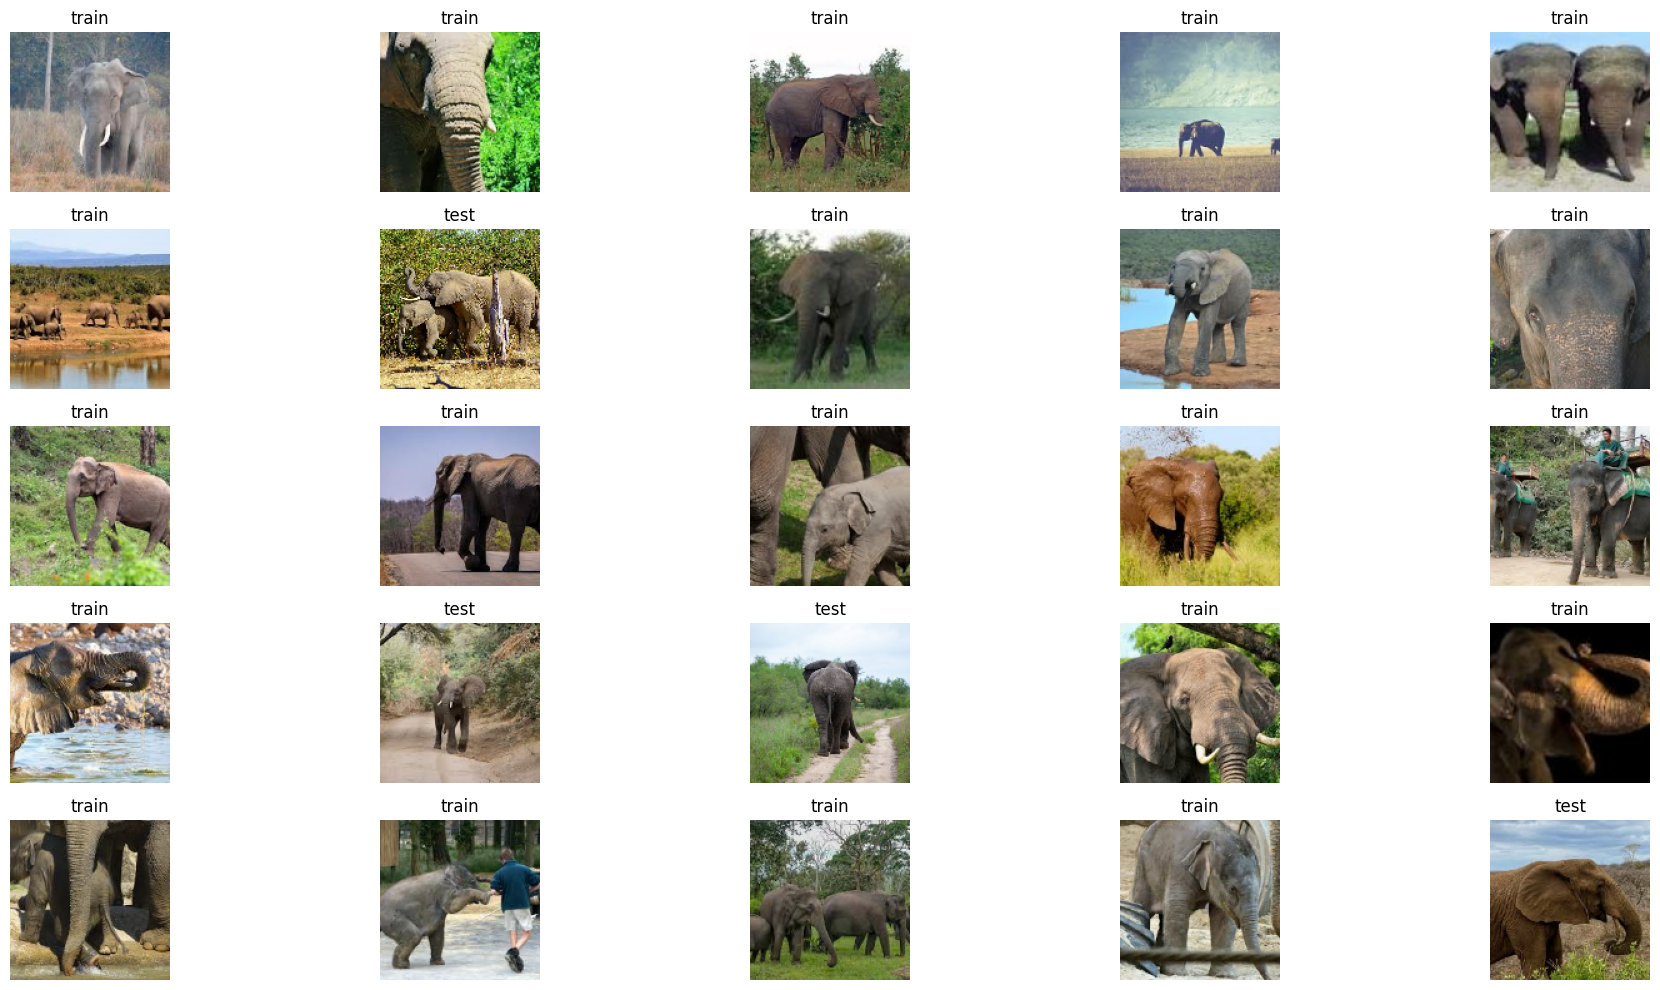

In [36]:
import matplotlib.pyplot as plt

for img_batch, label_batch in train_ds.take(1):
    plt.figure(figsize=(20,10))

    for i in range(25):
        ax = plt.subplot(5, 5, i + 1)        
        plt.imshow(img_batch[i].numpy().astype('uint8'))        
        label_index = label_batch[i].numpy()                       # converting the batches into a numpy array
        plt.title(train_ds.class_names[label_index])        
        plt.axis("off") 

plt.tight_layout()  
plt.show()

In [37]:
train_ds.class_names

['test', 'train']

In [38]:
for images, labels in train_ds.take(1):          # getting only one batch
    first_img = images[0]                        # getting only one image (very first img) from images
    first_label = labels[0]                      # getting only one label (very first label) from labels

    print(first_label)
    print(first_img)
    break

tf.Tensor(1, shape=(), dtype=int32)
tf.Tensor(
[[[196.61998  198.83482  214.1722  ]
  [187.09772  192.67584  210.67369 ]
  [189.21683  197.39165  218.05212 ]
  ...
  [129.21484  173.21484  208.21484 ]
  [128.85938  172.85938  207.85938 ]
  [128.21484  172.21484  208.78516 ]]

 [[204.95663  207.30995  220.88242 ]
  [197.28735  202.67917  218.09459 ]
  [189.6095   196.96497  215.42104 ]
  ...
  [131.28906  175.28906  210.28906 ]
  [130.51817  174.51817  209.51817 ]
  [130.28906  174.28906  210.85938 ]]

 [[180.792    184.792    195.64357 ]
  [193.95523  197.35854  210.69255 ]
  [194.32442  200.17047  214.17598 ]
  ...
  [134.22266  178.14844  213.14844 ]
  [133.29688  177.22266  212.22266 ]
  [133.2386   177.16438  213.61815 ]]

 ...

 [[ 96.896515 107.55699   38.77997 ]
  [112.38101  117.85361   56.959137]
  [125.6871   124.83554   70.538666]
  ...
  [ 82.90375  104.82953   59.052185]
  [ 78.58197  100.58197   54.58197 ]
  [ 82.45639  102.10092   56.886078]]

 [[ 99.8129   109.23047   4

In [39]:
for a, b in train_ds.take(1):
    print(b[:].numpy())
    print(train_ds.class_names[b[1].numpy()])

[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1]
train


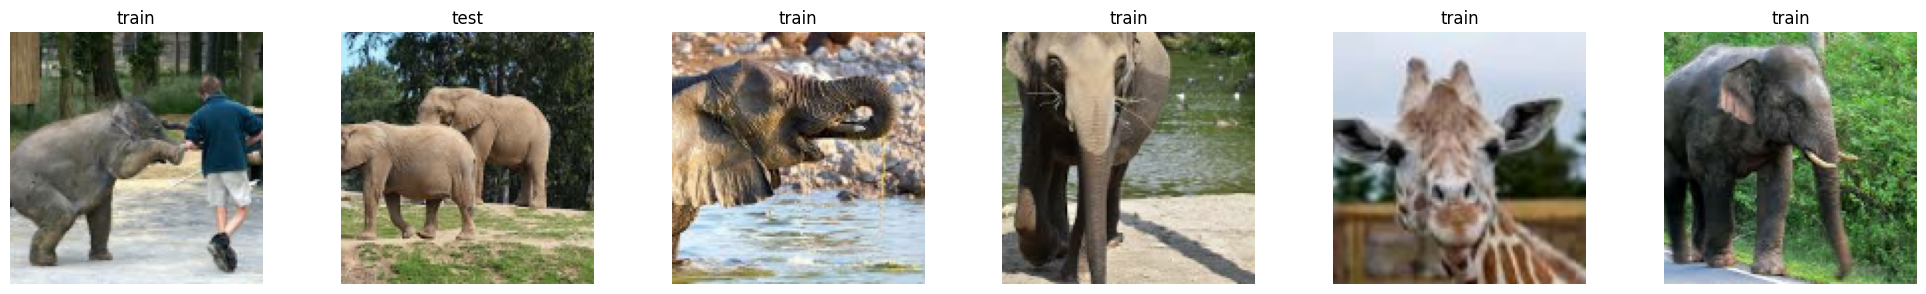

In [40]:
plt.figure(figsize=(20, 3))

for i, (images, labels) in enumerate(train_ds.take(6)):
    plt.subplot(1,6, i+1)
    plt.imshow(images[0].numpy().astype('uint8'))
    label = labels[i].numpy()
    plt.title(train_ds.class_names[label])
    plt.axis('off')
plt.tight_layout()
plt.show()

## Making full optuna model

### Making Pruning function

In [60]:
class PyKerasPruningCallback(keras.callbacks.Callback):
    def __init__(self, trial, monitor='val_accuracy'):
        super().__init__()
        self.trial = trial
        self.monitor = monitor

    def on_epoch_end(self, epoch, logs=None):
        log = logs or {}
        val = log.get(self.monitor)

        if val is None:
            return
        
        self.trial.report(val, epoch)

        if self.trial.should_prune():
            message = f"Trial pruned at epoch {epoch}."
            raise optuna.exceptions.TrialPruned(message)

In [61]:
from tensorflow.keras import layers, models, regularizers, optimizers, backend

def make_optuna_model(trial):
    backend.clear_session()

    # Hyperparameters
    conv_layer = trial.suggest_int("conv_layer", 1, 5)
    dense_layer = trial.suggest_int('dense_layer', 1, 8)
    lr = trial.suggest_float('lr', 1e-4, 1e-2, log=True)
    dropout_rate = trial.suggest_float('dropout_rate', 0.1, 0.5)
    
    reg_val = trial.suggest_float('reg', 1e-4, 1e-2, log=True)
    regularizer_type = trial.suggest_categorical('regularizers', ['l1', 'l2'])

    reg = regularizers.l1(reg_val) if regularizer_type == 'l1' else regularizers.l2(reg_val)

    temp_list = [
        layers.RandomFlip('horizontal', input_shape=(128,128, 3)),
        layers.RandomZoom(0.25),
        layers.RandomRotation(0.15),
        layers.Rescaling(1./255)
    ]

    count = 0
    for i in range(conv_layer):
        if count == 0:
            filters = trial.suggest_int(f'filter_{i}',16,64,step=16)
            temp_list.append(layers.Conv2D(filters=filters, kernel_size=(3,3), padding='same', activation='relu'))
            temp_list.append(layers.MaxPooling2D(pool_size=(2,2)))
            count += 1
        else:
            filters = trial.suggest_int(f'filter_{i}',32,160,step=20)
            temp_list.append(layers.Conv2D(filters=filters, kernel_size=(3,3), padding='valid', activation='relu'))
            temp_list.append(layers.MaxPooling2D(pool_size=(2,2)))

    temp_list.append(layers.Flatten())

    # Dense layers
    first_layer_neurons = trial.suggest_int('neuron_0', 30, 220, step=10)
    temp_list.append(layers.Dense(first_layer_neurons, activation='relu', kernel_regularizer=reg))
    temp_list.append(layers.Dropout(rate=dropout_rate))

    for i in range(1, dense_layer):
        neurons = trial.suggest_int(f"neuron_{i}", 13, first_layer_neurons, step=5)
        temp_list.append(layers.Dense(neurons, activation='relu', kernel_regularizer=reg))
        temp_list.append(layers.Dropout(rate=dropout_rate))

    temp_list.append(layers.Dense(1, activation='sigmoid'))

    model = models.Sequential(temp_list)

    model.compile(
        optimizer=optimizers.Adam(learning_rate=lr),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model

In [62]:
def objective(trial):
    model = make_optuna_model(trial)
    pruning_callback = PyKerasPruningCallback(trial, monitor='val_accuracy')

    history = model.fit(
        train_ds,
        validation_data =  val_ds,
        epochs=20,
        callbacks=[pruning_callback],
        verbose=0
    )

    return max(history.history['val_accuracy'])

In [63]:
import optuna

In [64]:
study = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(multivariate=True),
    pruner=optuna.pruners.HyperbandPruner()
)

study.optimize(objective, n_trials=10)

[I 2026-06-13 07:32:16,327] A new study created in memory with name: no-name-028deeaf-2fcb-4776-adf3-8d50044137b4
[I 2026-06-13 07:32:46,576] Trial 0 finished with value: 0.8243902325630188 and parameters: {'conv_layer': 1, 'dense_layer': 6, 'lr': 0.008724618689997549, 'dropout_rate': 0.4969299635169713, 'reg': 0.00045731526529414925, 'regularizers': 'l1', 'filter_0': 64, 'neuron_0': 40, 'neuron_1': 28, 'neuron_2': 28, 'neuron_3': 13, 'neuron_4': 33, 'neuron_5': 13}. Best is trial 0 with value: 0.8243902325630188.
[I 2026-06-13 07:33:19,098] Trial 1 finished with value: 0.8243902325630188 and parameters: {'conv_layer': 2, 'dense_layer': 6, 'lr': 0.000330448966902151, 'dropout_rate': 0.18529266339859574, 'reg': 0.0002215604464585848, 'regularizers': 'l1', 'filter_0': 16, 'filter_1': 132, 'neuron_0': 120, 'neuron_1': 23, 'neuron_2': 83, 'neuron_3': 33, 'neuron_4': 48, 'neuron_5': 68}. Best is trial 0 with value: 0.8243902325630188.
[I 2026-06-13 07:33:50,952] Trial 2 finished with value:

In [66]:
print(f"BEST ACCURACY : {study.best_trial.value}")
print(f"BEST PARAMETER : {study.best_trial.params}")

BEST ACCURACY : 0.8243902325630188
BEST PARAMETER : {'conv_layer': 1, 'dense_layer': 6, 'lr': 0.008724618689997549, 'dropout_rate': 0.4969299635169713, 'reg': 0.00045731526529414925, 'regularizers': 'l1', 'filter_0': 64, 'neuron_0': 40, 'neuron_1': 28, 'neuron_2': 28, 'neuron_3': 13, 'neuron_4': 33, 'neuron_5': 13}


In [73]:
study.best_trial

FrozenTrial(number=0, state=<TrialState.COMPLETE: 1>, values=[0.8243902325630188], datetime_start=datetime.datetime(2026, 6, 13, 7, 32, 16, 329129), datetime_complete=datetime.datetime(2026, 6, 13, 7, 32, 46, 576439), params={'conv_layer': 1, 'dense_layer': 6, 'lr': 0.008724618689997549, 'dropout_rate': 0.4969299635169713, 'reg': 0.00045731526529414925, 'regularizers': 'l1', 'filter_0': 64, 'neuron_0': 40, 'neuron_1': 28, 'neuron_2': 28, 'neuron_3': 13, 'neuron_4': 33, 'neuron_5': 13}, user_attrs={}, system_attrs={}, intermediate_values={0: 0.8243902325630188, 1: 0.8243902325630188, 2: 0.8243902325630188, 3: 0.8243902325630188, 4: 0.8243902325630188, 5: 0.8243902325630188, 6: 0.8243902325630188, 7: 0.8243902325630188, 8: 0.8243902325630188, 9: 0.8243902325630188, 10: 0.8243902325630188, 11: 0.8243902325630188, 12: 0.8243902325630188, 13: 0.8243902325630188, 14: 0.8243902325630188, 15: 0.8243902325630188, 16: 0.8243902325630188, 17: 0.8243902325630188, 18: 0.8243902325630188, 19: 0.8243

In [77]:
model = make_optuna_model(study.best_trial)

history = model.fit(
    train_ds,
    validation_data = val_ds,
    epochs=15
)


Epoch 1/15
26/26 ━━━━━━━━━━━━━━━━━━━━ 5s 54ms/step - accuracy: 0.7546 - loss: 24.1824 - val_accuracy: 0.8244 - val_loss: 11.2802
Epoch 2/15
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - accuracy: 0.8153 - loss: 8.1029 - val_accuracy: 0.8244 - val_loss: 6.4377
Epoch 3/15
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - accuracy: 0.8153 - loss: 5.9498 - val_accuracy: 0.8244 - val_loss: 6.0519
Epoch 4/15
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - accuracy: 0.8153 - loss: 5.7184 - val_accuracy: 0.8244 - val_loss: 5.2082
Epoch 5/15
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - accuracy: 0.8153 - loss: 5.7401 - val_accuracy: 0.8244 - val_loss: 6.1626
Epoch 6/15
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - accuracy: 0.8153 - loss: 5.7769 - val_accuracy: 0.8244 - val_loss: 5.8743
Epoch 7/15
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - accuracy: 0.8153 - loss: 5.7979 - val_accuracy: 0.8244 - val_loss: 5.5703
Epoch 8/15
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - accuracy: 0.8153 - loss: 5.8001 - val_accuracy: 0.8244 -

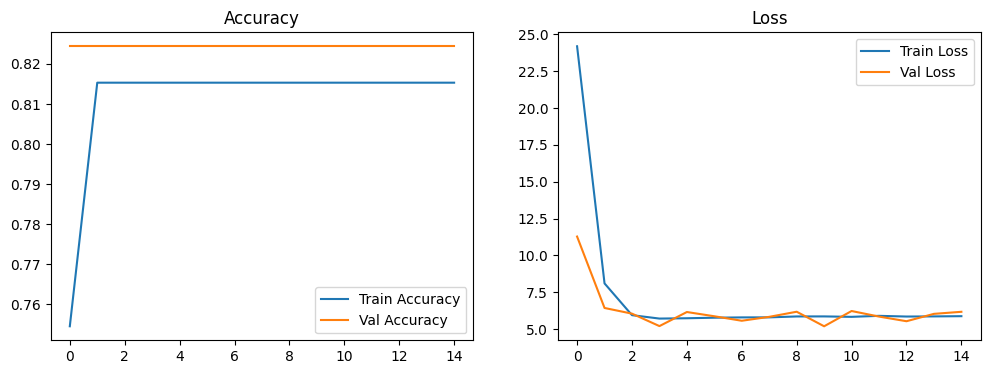

In [78]:
plt.figure(figsize=(12, 4))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.legend()
plt.title('Accuracy')

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title('Loss')

plt.show()